# Segmenting the Data - Wine Clustering Dataset

**Problem Statement:** Scale the features, then apply K-Means (using the elbow method to pick k) and DBSCAN to the same data,
and compare the groupings they produce. Use PCA to reduce the data to 2 dimensions and visualize the clusters from both
algorithms on a scatter plot.

## 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

## 2. Loading the Dataset

In [2]:
df = pd.read_csv("wine-clustering.csv")

In [3]:
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df.shape

(178, 13)

* The dataset has 178 rows and 13 chemical-analysis features per wine sample, with no target/label column since this is an unsupervised task.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


* All 13 features are numeric, so no categorical encoding is needed before scaling.

In [6]:
df.isnull().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

* There are zero missing values in any column.

In [7]:
df.duplicated().sum()

np.int64(0)

* There are zero duplicate rows, so the full dataset can be used as-is.

In [8]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


* Features are on very different scales (e.g. `Proline` in the hundreds vs `Hue` under 2), so scaling is essential before any distance-based clustering.

## 3. Feature Scaling

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled.shape

(178, 13)

* After scaling, every feature has mean 0 and standard deviation 1, putting all 13 features on equal footing for K-Means and DBSCAN, both of which rely on Euclidean distance.

## 4. K-Means: Choosing k with the Elbow Method

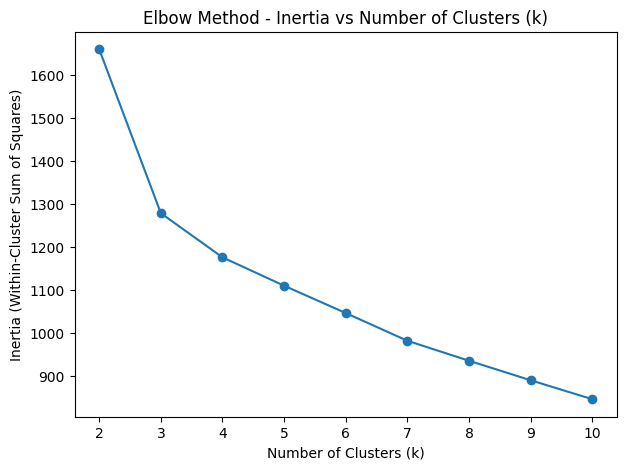

In [10]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

plt.figure(figsize=(7,5))
plt.plot(list(k_range), inertias, marker='o')
plt.title("Elbow Method - Inertia vs Number of Clusters (k)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(list(k_range))
plt.show()

* The inertia curve bends most sharply at k=3, after which additional clusters reduce inertia only gradually, marking k=3 as the elbow point.

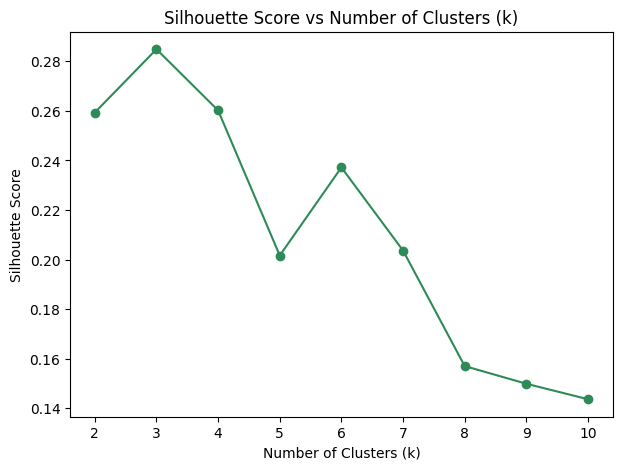

In [11]:
plt.figure(figsize=(7,5))
plt.plot(list(k_range), silhouette_scores, marker='o', color='seagreen')
plt.title("Silhouette Score vs Number of Clusters (k)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_range))
plt.show()

* The silhouette score peaks at k=3 (about 0.285), confirming the elbow method's choice with an independent metric.

## 5. Fitting K-Means with k=3

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels
df['KMeans_Cluster'].value_counts().sort_index()

KMeans_Cluster
0    65
1    51
2    62
Name: count, dtype: int64

* K-Means splits the 178 wines into three fairly balanced groups of 65, 51 and 62 samples.

## 6. DBSCAN: Choosing eps with a k-Distance Plot

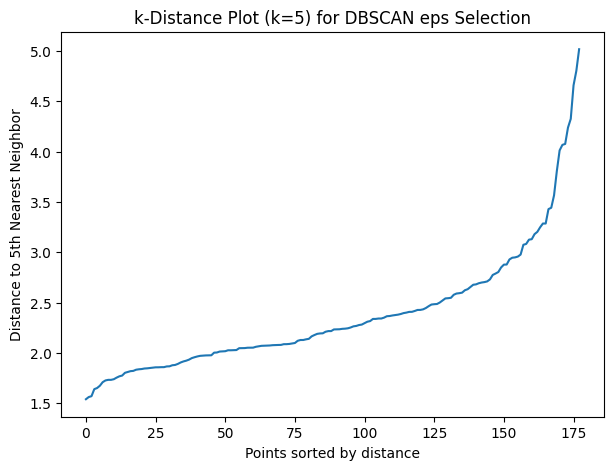

In [13]:
neigh = NearestNeighbors(n_neighbors=5)
neigh.fit(X_scaled)
distances, _ = neigh.kneighbors(X_scaled)
k_distances = np.sort(distances[:, 4])

plt.figure(figsize=(7,5))
plt.plot(k_distances)
plt.title("k-Distance Plot (k=5) for DBSCAN eps Selection")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 5th Nearest Neighbor")
plt.show()

* The curve's knee sits roughly between eps=2.0 and eps=2.3, so we search that neighborhood for the eps value that yields sensible clusters rather than one giant blob or all noise.

In [14]:
dbscan = DBSCAN(eps=2.1, min_samples=4)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels
df['DBSCAN_Cluster'].value_counts().sort_index()

DBSCAN_Cluster
-1    57
 0    84
 1    13
 2    24
Name: count, dtype: int64

* With eps=2.1 and min_samples=4, DBSCAN finds 3 clusters (84, 13 and 24 points) and labels 57 points (about 32% of the data) as noise (-1), since the wine groups overlap and aren't cleanly density-separated in 13 dimensions.

## 7. Comparing K-Means and DBSCAN Groupings

In [15]:
comparison = pd.crosstab(df['KMeans_Cluster'], df['DBSCAN_Cluster'])
comparison

DBSCAN_Cluster,-1,0,1,2
KMeans_Cluster,,,,
0,31,34,0,0
1,14,0,13,24
2,12,50,0,0


* DBSCAN's dense cluster 0 (84 points) mostly absorbs K-Means clusters 0 and 2 together, while K-Means cluster 1 (the highest-acidity group) is the one DBSCAN fragments into its smaller clusters 1 and 2 plus much of the noise — showing DBSCAN struggles most with the group that has the least density separation from its neighbors.

## 8. Dimensionality Reduction with PCA (2D)

In [16]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained by 2 components:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.36198848 0.1920749 ]
Total variance explained by 2 components: 0.5540633835693527


* The first two principal components together explain about 55% of the total variance, so the 2D plot below is a reasonable but simplified view of the true 13-dimensional structure.

## 9. Visualizing K-Means Clusters in PCA Space

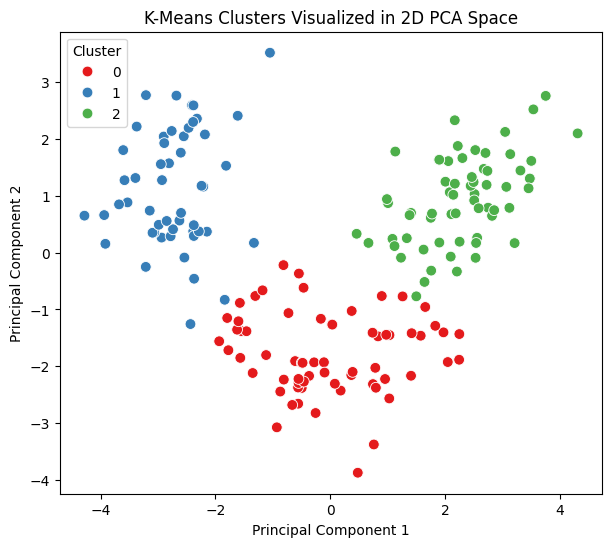

In [17]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=kmeans_labels, palette='Set1', s=60)
plt.title("K-Means Clusters Visualized in 2D PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

* K-Means produces three visually distinct, well-separated groups along PC1, matching the three known wine cultivars this dataset is derived from.

## 10. Visualizing DBSCAN Clusters in PCA Space

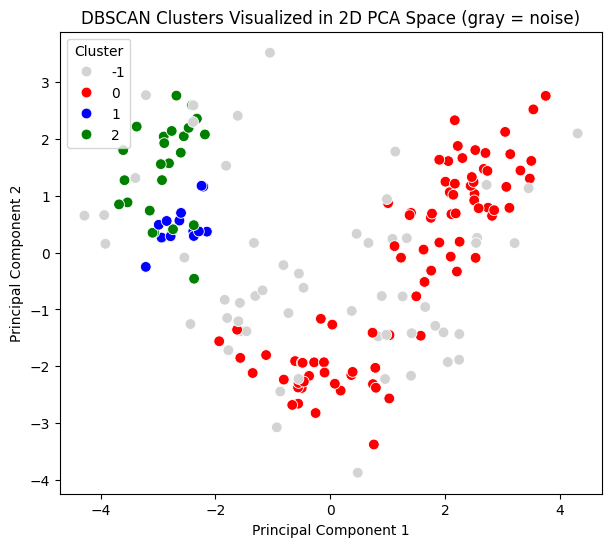

In [18]:
plt.figure(figsize=(7,6))
palette = {-1: 'lightgray', 0: 'red', 1: 'blue', 2: 'green'}
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=dbscan_labels, palette=palette, s=60)
plt.title("DBSCAN Clusters Visualized in 2D PCA Space (gray = noise)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

* DBSCAN's clusters occupy similar regions of the PCA plot as K-Means, but the boundary/transition points between groups are marked gray (noise) instead of being forced into a cluster, visibly thinning out the edges of each group.

## 11. Side-by-Side Comparison

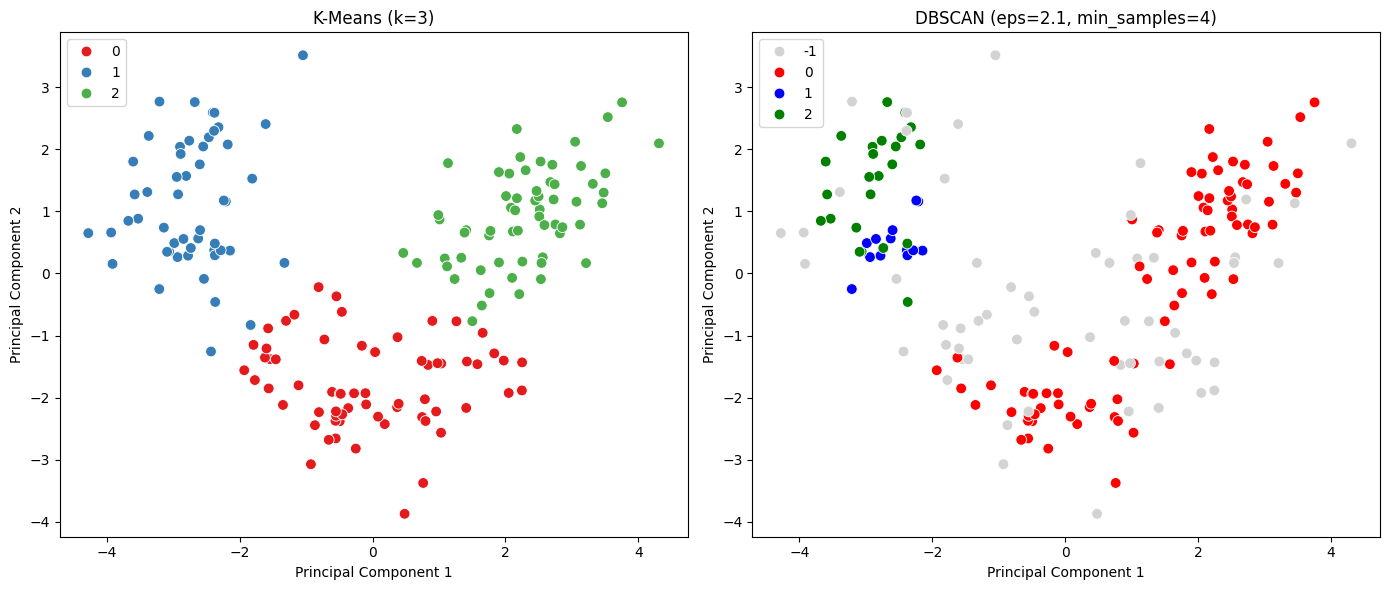

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=kmeans_labels, palette='Set1', s=60, ax=axes[0])
axes[0].set_title("K-Means (k=3)")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=dbscan_labels, palette=palette, s=60, ax=axes[1])
axes[1].set_title("DBSCAN (eps=2.1, min_samples=4)")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

* Placed side by side, K-Means assigns every point to one of three clean groups while DBSCAN carves out the same three dense cores but leaves a meaningful fringe of ambiguous points unassigned, which is a key structural difference between the two algorithms.

## 12. Profiling What Each Cluster Represents

In [20]:
cluster_profile = df.groupby('KMeans_Cluster')[
    ['Alcohol','Malic_Acid','Total_Phenols','Flavanoids','Color_Intensity','Proline']
].mean().round(2)
cluster_profile

,Alcohol,Malic_Acid,Total_Phenols,Flavanoids,Color_Intensity,Proline
KMeans_Cluster,,,,,,
0,12.25,1.90,2.25,2.05,2.97,510.17
1,13.13,3.31,1.68,0.82,7.23,619.06
2,13.68,2.00,2.85,3.00,5.45,1100.23


* Cluster 2 stands out with the highest alcohol, phenols and by far the highest proline, cluster 1 has the highest malic acid but the lowest phenols, and cluster 0 sits in between on most measures — a chemical fingerprint consistent with three different wine cultivars.

## 13. Conclusion: What Each Cluster Represents

* **Cluster 0 (K-Means, 65 wines):** Moderate alcohol (~12.3%) and phenol levels with the lowest average `Proline` (~510), suggesting a lighter-bodied wine style.
* **Cluster 1 (K-Means, 51 wines):** The highest average `Malic_Acid` (~3.3) but the lowest `Total_Phenols` (~1.7), indicating a more acidic, less tannic wine profile — and this is also the group DBSCAN fragments most, since it overlaps more with its neighbors than it is internally dense.
* **Cluster 2 (K-Means, 62 wines):** The highest alcohol content (~13.7%), highest `Total_Phenols` and by far the highest `Proline` (~1,100), consistent with a full-bodied, higher-quality wine style.
* **K-Means vs DBSCAN:** Both algorithms recover the same three underlying chemical profiles, but K-Means forces every wine into one of the three groups, while DBSCAN only commits the ~68% of wines sitting in dense cores to a cluster and flags the remaining ~32% as noise/transitional wines that don't clearly belong to any single profile.